**Import Libraries**

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.preprocessing import StandardScaler

**Load the dataset and add column names**

In [69]:
path = "/content/auto.csv"

columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

df = pd.read_csv(path, names=columns)

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [70]:
print("Dataset shape:", df.shape)

df.head(10)

Dataset shape: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


**Replace missing values**

In [71]:
df.replace("?", np.nan, inplace=True)

df.isnull().sum()

,0
symboling,0
normalized-losses,41
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


**Convert important columns to numeric**

In [72]:
numeric_columns = [
    "normalized-losses", "bore", "stroke", "horsepower",
    "peak-rpm", "price"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

**Fill missing values**

In [73]:
df["normalized-losses"] = df["normalized-losses"].fillna(df["normalized-losses"].mean())
df["bore"] = df["bore"].fillna(df["bore"].mean())
df["stroke"] = df["stroke"].fillna(df["stroke"].mean())
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())
df["peak-rpm"] = df["peak-rpm"].fillna(df["peak-rpm"].mean())

df["num-of-doors"] = df["num-of-doors"].fillna(df["num-of-doors"].mode()[0])

**Descriptive statisctics**

In [74]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,31.681008,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.519211,476.979093,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,122.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


**Mean, Median, Standard Deviation**

In [75]:
print("Mean values:")
print(df[["price", "horsepower", "engine-size", "city-mpg"]].mean())

print("\nMedian values:")
print(df[["price", "horsepower", "engine-size", "city-mpg"]].median())

print("\nStandard deviation:")
print(df[["price", "horsepower", "engine-size", "city-mpg"]].std())

Mean values:
price          13207.129353
horsepower       104.256158
engine-size      126.907317
city-mpg          25.219512
dtype: float64

Median values:
price          10295.0
horsepower        95.0
engine-size      120.0
city-mpg          24.0
dtype: float64

Standard deviation:
price          7947.066342
horsepower       39.519211
engine-size      41.642693
city-mpg          6.542142
dtype: float64


In [76]:
df.dtypes

,0
symboling,int64
normalized-losses,float64
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [77]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(col)
    print(df[col].unique())
    print()

make
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

fuel-type
['gas' 'diesel']

aspiration
['std' 'turbo']

num-of-doors
['two' 'four']

body-style
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

drive-wheels
['rwd' 'fwd' '4wd']

engine-location
['front' 'rear']

engine-type
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']

num-of-cylinders
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']

fuel-system
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']



**Histogram of Price**

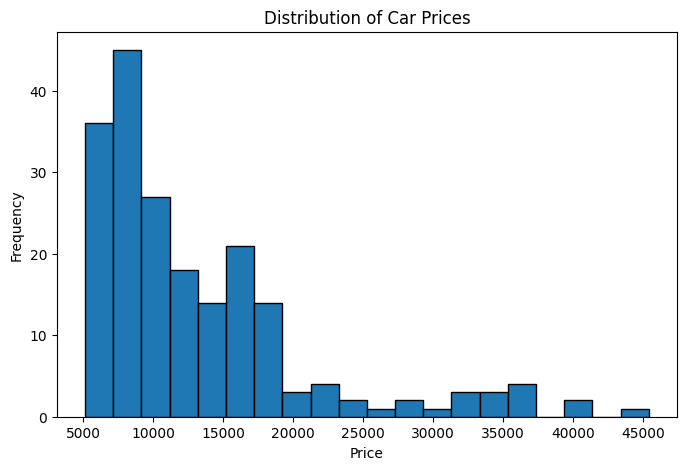

In [78]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=20, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Histogram of Horsepower**

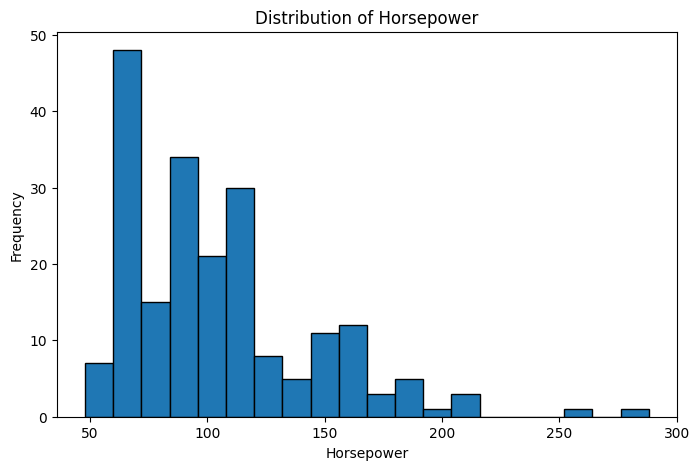

In [79]:
plt.figure(figsize=(8, 5))
plt.hist(df["horsepower"], bins=20, edgecolor="black")
plt.title("Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")
plt.show()

**Boxplot price vs body-style**

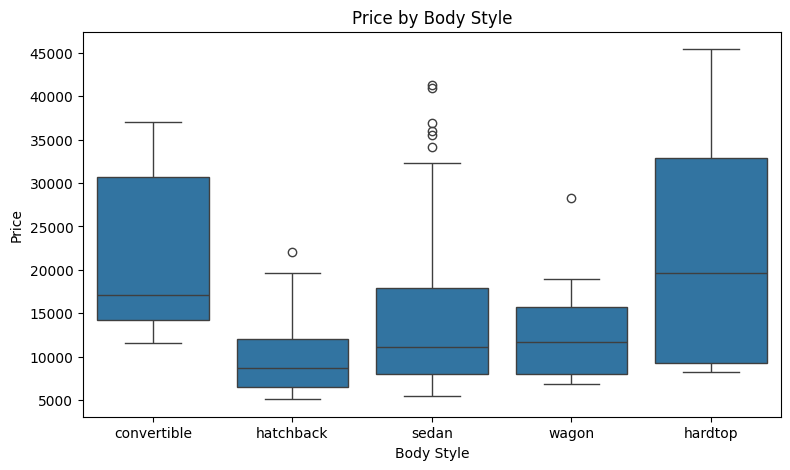

In [80]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="body-style", y="price", data=df)
plt.title("Price by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price")
plt.show()

**Correlation Heatmap**

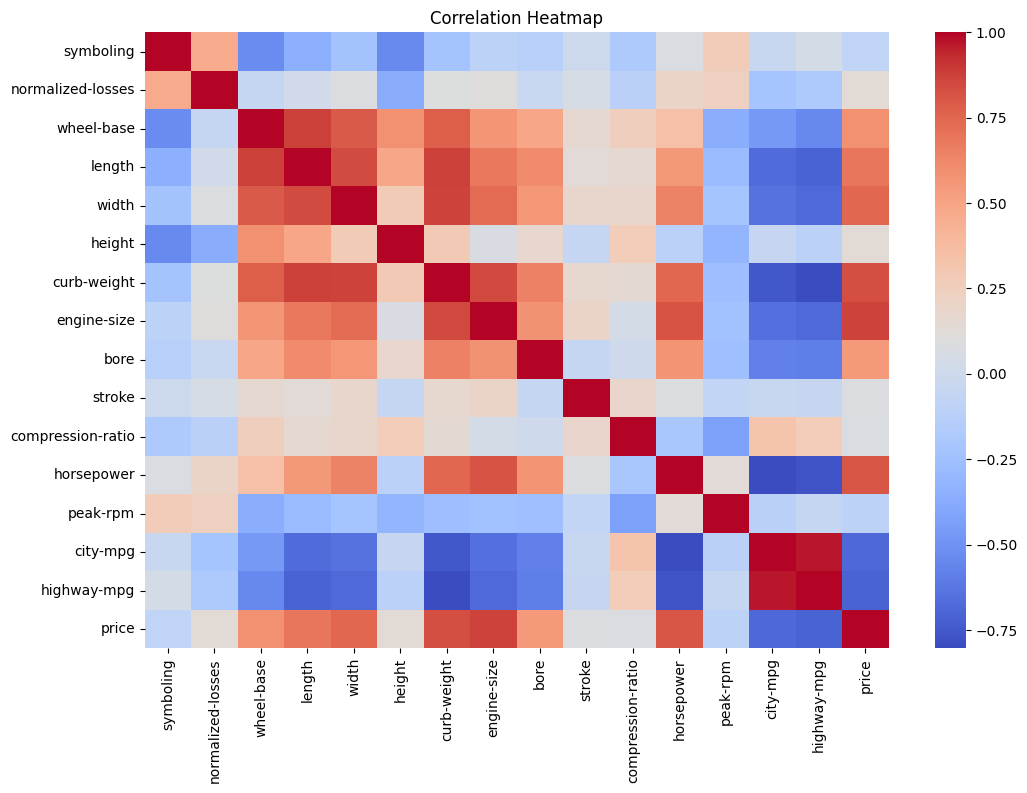

In [81]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Create new feature city-L/100km**

In [82]:
df["city-L/100km"] = 235 / df["city-mpg"]

df[["city-mpg", "city-L/100km"]].head()

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


**Horsepower binning**

In [83]:
bins = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 4)
labels = ["Low", "Medium", "High"]

df["horsepower-binned"] = pd.cut(df["horsepower"], bins=bins, labels=labels, include_lowest=True)

df[["horsepower", "horsepower-binned"]].head()

,horsepower,horsepower-binned
0,111.0,Low
1,111.0,Low
2,154.0,Medium
3,102.0,Low
4,115.0,Low


In [84]:
df["horsepower-binned"].value_counts()

,count
horsepower-binned,
Low,163
Medium,40
High,2


**Normalize one feature**

In [85]:
df["length-normalized"] = df["length"] / df["length"].max()

df[["length", "length-normalized"]].head()

,length,length-normalized
0,168.8,0.811148
1,168.8,0.811148
2,171.2,0.822681
3,176.6,0.848630
4,176.6,0.848630


**Features for Regression**

In [86]:
features = ["horsepower", "engine-size", "curb-weight", "width", "city-L/100km"]

X = df[features]
y = df["price"]

In [87]:
# Remove rows where target value price is missing
df = df.dropna(subset=["price"])

# Select features and target again after removing missing price
features = ["horsepower", "engine-size", "curb-weight", "highway-mpg", "city-mpg"]
X = df[features]
y = df["price"]

# Fill missing feature values
X = X.fillna(X.mean())

**80/20 split**

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [89]:
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)

print("Linear Regression Results - 80/20 Split")
print("R2 Score:", lr_r2)
print("MAE:", lr_mae)
print("MSE:", lr_mse)

Linear Regression Results - 80/20 Split
R2 Score: 0.7629787389670174
MAE: 3785.4622154216518
MSE: 28998786.439375088


**Random Forest Regressor**

In [90]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [91]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)

print("Random Forest Results - 80/20 Split")
print("R2 Score:", rf_r2)
print("MAE:", rf_mae)
print("MSE:", rf_mse)

Random Forest Results - 80/20 Split
R2 Score: 0.9279689321394141
MAE: 1847.5172723577234
MSE: 8812768.714442868


**Compare 80/20 and 70/30 split**

In [92]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.30, random_state=42
)

lr_model_70 = LinearRegression()
lr_model_70.fit(X_train_70, y_train_70)

y_pred_lr_70 = lr_model_70.predict(X_test_70)

print("Linear Regression Results - 70/30 Split")
print("R2 Score:", r2_score(y_test_70, y_pred_lr_70))
print("MAE:", mean_absolute_error(y_test_70, y_pred_lr_70))
print("MSE:", mean_squared_error(y_test_70, y_pred_lr_70))

Linear Regression Results - 70/30 Split
R2 Score: 0.7714568010786038
MAE: 3179.202022386861
MSE: 21663988.803818204


In [93]:
rf_model_70 = RandomForestRegressor(random_state=42)
rf_model_70.fit(X_train_70, y_train_70)

y_pred_rf_70 = rf_model_70.predict(X_test_70)

print("Random Forest Results - 70/30 Split")
print("R2 Score:", r2_score(y_test_70, y_pred_rf_70))
print("MAE:", mean_absolute_error(y_test_70, y_pred_rf_70))
print("MSE:", mean_squared_error(y_test_70, y_pred_rf_70))

Random Forest Results - 70/30 Split
R2 Score: 0.9122669284102649
MAE: 1930.6544480874318
MSE: 8316363.3379363865


**Actual Vs Predicted graph**

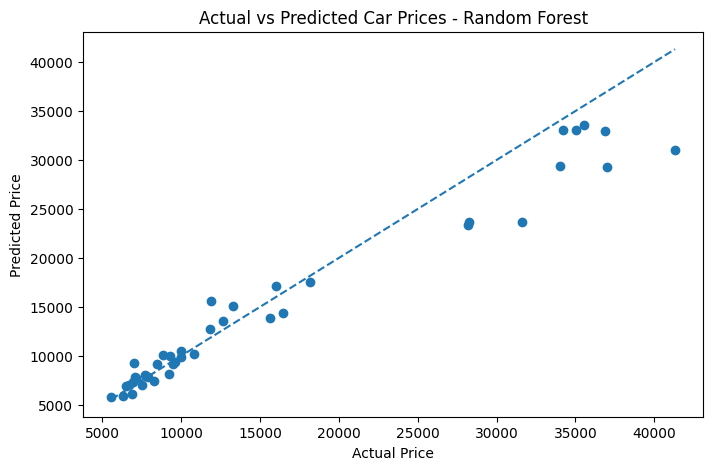

In [94]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices - Random Forest")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

**price categories for classification**

In [95]:
df["price-category"] = pd.qcut(
    df["price"],
    3,
    labels=["Low", "Medium", "High"]
)

df[["price", "price-category"]].head()

,price,price-category
0,13495.0,Medium
1,16500.0,High
2,16500.0,High
3,13950.0,High
4,17450.0,High


**Logistic Regression classification**

In [96]:
X_class = df[features]
y_class = df["price-category"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.20, random_state=42
)

scaler = StandardScaler()

X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c_scaled, y_train_c)

y_pred_class = log_model.predict(X_test_c_scaled)

In [97]:
accuracy = accuracy_score(y_test_c, y_pred_class)

print("Classification Accuracy:", accuracy)

Classification Accuracy: 0.7560975609756098


**Confusion Matrix**

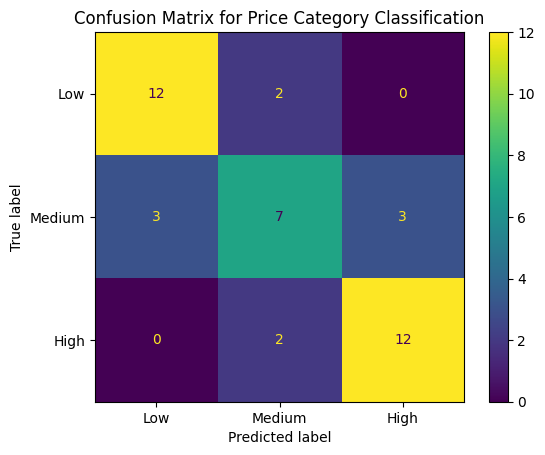

In [98]:
cm = confusion_matrix(y_test_c, y_pred_class, labels=["Low", "Medium", "High"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot()
plt.title("Confusion Matrix for Price Category Classification")
plt.show()

**Final Model Comparison**

In [99]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "MSE": [lr_mse, rf_mse]
})

results

,Model,R2 Score,MAE,MSE
0,Linear Regression,0.762979,3785.462215,2.899879e+07
1,Random Forest,0.927969,1847.517272,8.812769e+06


**Clean Dataset Saving**

In [100]:
df.to_csv("cleaned_car_price_data.csv", index=False)